In [31]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
sns.set_theme(font_scale=2,palette='colorblind')

In [33]:
tips_df = sns.load_dataset('tips')
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [35]:
tips_X = tips_df['total_bill'].values[:,np.newaxis]
tips_y = tips_df['tip']

In [37]:
tips_X_train, tips_X_test, tips_y_train, tips_y_test = train_test_split(tips_X,tips_y)

In [39]:
regr = linear_model.LinearRegression()

In [43]:
regr.fit(tips_X_train,tips_y_train)

LinearRegression()

In [45]:
regr.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'n_features_in_': 1,
 'coef_': array([0.10226248]),
 'rank_': 1,
 'singular_': array([115.0701792]),
 'intercept_': 0.9940275537136081}

In [48]:
tips_y_pred = regr.predict(tips_X_test)

In [50]:
slope = regr.coef_
slope

array([0.10226248])

In [52]:
intercept = regr.intercept_
intercept

0.9940275537136081

In [55]:
slope*tips_X_test[0] + intercept

array([2.53410052])

In [57]:
tips_y_pred[0]

2.534100519398767

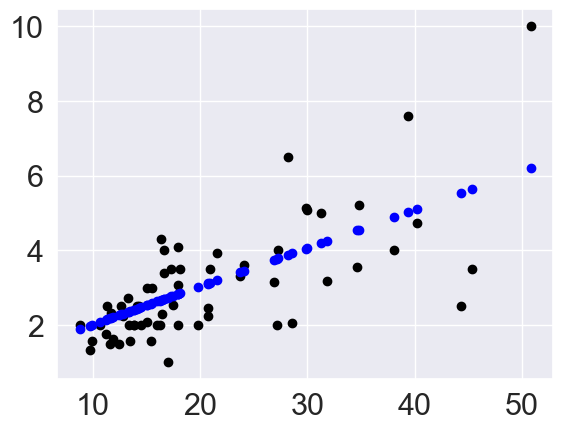

In [60]:
plt.scatter(tips_X_test,tips_y_test, color='black')
plt.scatter(tips_X_test,tips_y_pred, color='blue')

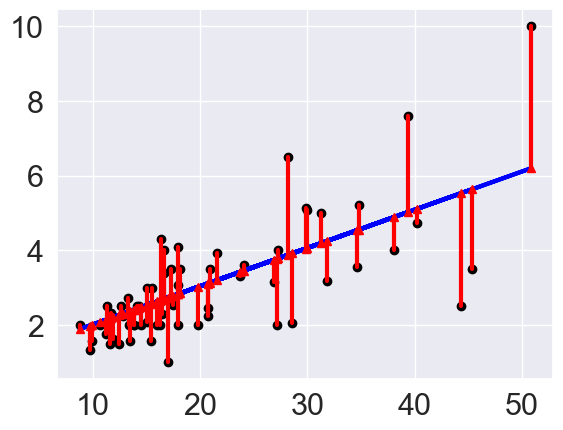

In [62]:
# plot line prediction
plt.plot(tips_X_test, tips_y_pred, color='blue', linewidth=3);

# draw vertical lines from each data point to its predict value
[plt.plot([x,x],[yp,yt], color='red', linewidth=3, markevery=[0], marker ='^')
                 for x, yp, yt in zip(tips_X_test, tips_y_pred,tips_y_test)];

# plot these last so they are visually on top
plt.scatter(tips_X_test, tips_y_test,  color='black');


In [66]:
mean_squared_error(tips_y_test,tips_y_pred)


1.2373562689763027

In [68]:
np.mean((tips_y_test-tips_y_pred)**2)


1.2373562689763027

In [72]:
mean_abs_error = np.sqrt(mean_squared_error(tips_y_test,tips_y_pred))
mean_abs_error

1.1123651688974725

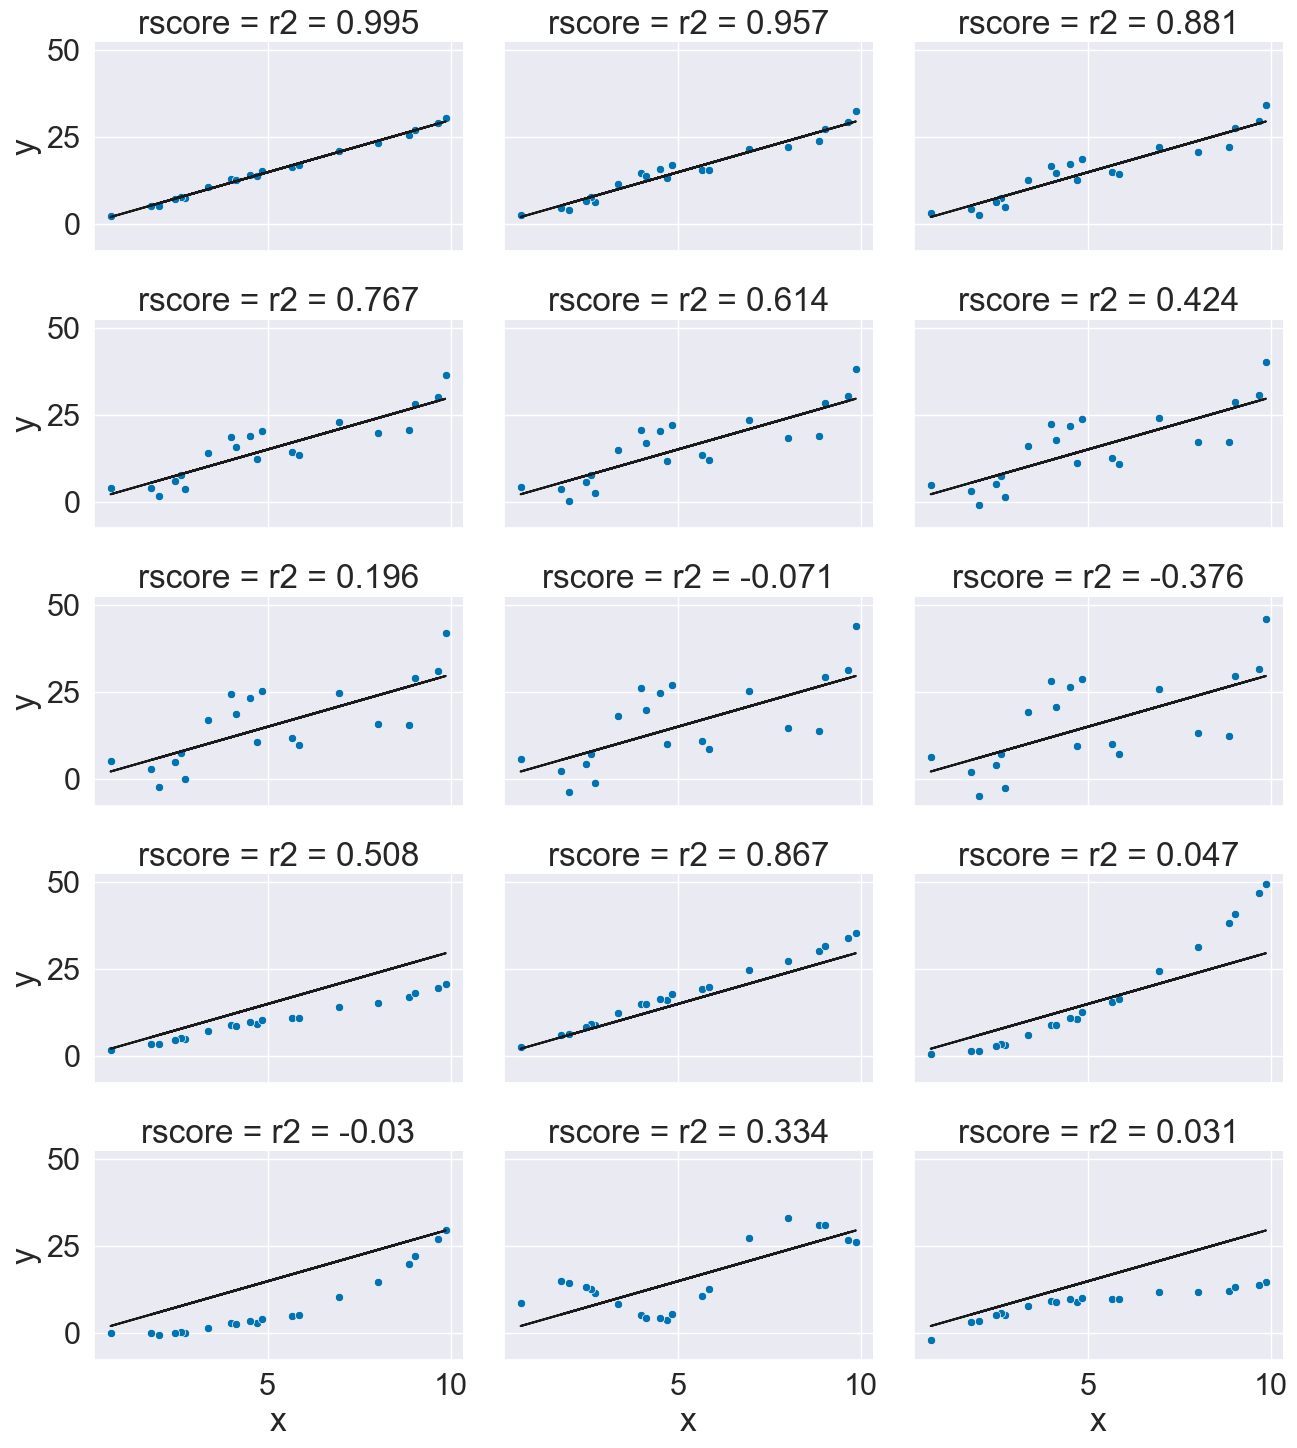

In [74]:
# pick some random points
x = 10*np.random.random(20)
# make a line with a fixed slope
y_pred = 3*x
# put it in a data frame
ex_df = pd.DataFrame(data = x,columns = ['x'])
ex_df['y_pred'] = y_pred
# set some amounts of noise
n_levels = range(1,18,2)
# sample random noies
noise = (np.random.random(20)-.5)*2
# add the noise and put it in the data frame with col title the r2
for n in n_levels:
    y_true = y_pred + n* noise
    ex_df['r2 = '+ str(np.round(r2_score(y_pred,y_true),3))] = y_true

# set some other functions
f_x_list = [2*x,3.5*x,.5*x**2, .03*x**3, 10*np.sin(x)+x*3,3*np.log(x**2)]
# add them to the noise and store with r2 col title
for fx in f_x_list:
    y_true = fx + noise
    ex_df['r2 = '+ str(np.round(r2_score(y_pred,y_true),3))] = y_true    

# make the data tidy for plotting
xy_df = ex_df.melt(id_vars=['x','y_pred'],var_name='rscore',value_name='y')
# make a custom grid by using facet grid directly
g = sns.FacetGrid(data = xy_df,col='rscore',col_wrap=3,aspect=1.5,height=3)
# plot the lin
g.map(plt.plot, 'x','y_pred',color='k')
# plot the dta
g.map(sns.scatterplot, "x", "y",)


In [77]:
r2_score(tips_y_test,tips_y_pred)


0.49353650826561524